<a href="https://colab.research.google.com/github/Tatutina/COVID-19_Project/blob/code/%D0%9A%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_%D0%A1OVID_19_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 2. Создайте структуру папок проекта
!mkdir -p /content/COVID19_Project/{code,data,reports}
!mkdir -p /content/drive/MyDrive/COVID19_Project/{code,data,reports}

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [5]:
import kagglehub
import pandas as pd
import os

# Скачивание датасета (если еще не сделано)
path = kagglehub.dataset_download("eshaalnmalik/covid-19-recovery-dataset")
print("Путь к датасету:", path)

# Просмотр файлов в датасете
print("Файлы:", os.listdir(path))

# Загрузка CSV (замените на реальное имя файла из списка выше)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))  # первый CSV
    print(f"Загружен {csv_files[0]}")
    print("Форма:", df.shape)
    print("\nПервые строки:")
    print(df.head())
    print("\nИнформация:")
    print(df.info())
else:
    print("CSV файлы не найдены")


100%|██████████| 1.68M/1.68M [00:00<00:00, 69.3MB/s]

Extracting files...
Путь к датасету: /root/.cache/kagglehub/datasets/eshaalnmalik/covid-19-recovery-dataset/versions/1
Файлы: ['COVID-19_RECOVERY_DATASET.csv']


Загружен COVID-19_RECOVERY_DATASET.csv
Форма: (70000, 28)

Первые строки:
  patient_id   country region/state  date_reported  age  gender comorbidities  \
0    P000001     India        Sindh          44447   95  Female      Diabetes   
1    P000002  Pakistan       London          43930   92  Female      Diabetes   
2    P000003   Germany       Berlin          44718   78  Female           NaN   
3    P000004     India    Cape Town          44107   36  Female        Cancer   
4    P000005        UK       Berlin          44083   99    Male      Diabetes   

      symptoms_1     symptoms_2     symptoms_3  ... days_to_recovery  \
0          Cough            NaN            NaN  ...               18   
1  Loss of Smell        Fatigue        Fatigue  ...                9   
2       Headache  Loss of Smell  Loss of Smell  ...               27   
3          Cough        Fatigue        Fatigue  ...               25   
4        Fatigue            NaN            NaN  ...               17   

   rec

In [6]:
df.columns

Index(['patient_id', 'country', 'region/state', 'date_reported', 'age',
       'gender', 'comorbidities', 'symptoms_1', 'symptoms_2', 'symptoms_3',
       'severity', 'hospitalized', 'icu_admission', 'ventilator_support',
       'vaccination_status', 'variant', 'treatment_given_1',
       'treatment_given_2', 'days_to_recovery', 'recovered', 'death',
       'date_of_recovery', 'date_of_death', 'tests_conducted', 'test_type',
       'hospital_name', 'doctor_assigned', 'source_url'],
      dtype='object')

In [7]:
# Получение списка числовых признаков
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# Выводим результат
print(numeric_columns)

['date_reported', 'age', 'hospitalized', 'icu_admission', 'ventilator_support', 'days_to_recovery', 'recovered', 'death', 'date_of_recovery', 'date_of_death', 'tests_conducted']


In [8]:
#список неинформативных признаков
low_information = []

#цикл по всем столбцам
for col in df.columns:
    #наибольшая относительная частота в признаке
    top_freq = df[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = df[col].nunique() / df[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

patient_id: 100.0% уникальных значений
source_url: 100.0% одинаковых значений


In [9]:
# Удаление неинформотивных признаков
columns_to_remove = ["patient_id", 'source_url', 'country', 'region/state',
                     'date_reported', 'date_of_recovery', 'date_of_death','hospital_name', 'doctor_assigned',]
df = df.drop(columns=columns_to_remove)


## Обнавленная информация

In [10]:
def analyze_data(df, categorical_threshold=20):
    """
    Анализ данных и определение типов столбцов
    """
    print("\n🔍 АНАЛИЗ ДАННЫХ:")
    print("-" * 40)

    # Проверяем пропуски
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100

    print("📊 ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")
    has_missing = False
    missing_cols = []

    for col in df.columns:
        if missing[col] > 0:
            has_missing = True
            missing_cols.append(col)
            print(f"  ⚠️  {col}: {missing[col]} пропусков ({missing_percent[col]:.1f}%)")

    if not has_missing:
        print("  ✅ Пропущенных значений нет")
    else:
        print(f"\n  📈 Всего столбцов с пропусками: {len(missing_cols)}")

    # Определяем типы столбцов
    categorical_cols = []
    numeric_cols = []

    print("\n🎯 ОПРЕДЕЛЕНИЕ ТИПОВ СТОЛБЦОВ:")
    print("-" * 40)

    for col in df.columns:
        dtype = df[col].dtype
        unique_count = df[col].nunique()

        if dtype == 'object':
            # Проверяем, может быть это числовые данные в строковом формате
            sample_values = df[col].dropna().head(5)
            has_slash = any(isinstance(v, str) and '/' in v for v in sample_values)
            has_comma = any(isinstance(v, str) and ',' in v for v in sample_values)

            if has_slash or has_comma:
                numeric_cols.append(col)
                print(f"  🔧 {col}: Строка → Числовой (есть '/', или ',')")
            elif unique_count <= categorical_threshold:
                categorical_cols.append(col)
                print(f"  🏷️  {col}: Категориальный ({unique_count} значений)")
            else:
                print(f"  📝 {col}: Текстовый/ID ({unique_count} значений)")
                categorical_cols.append(col)

        elif dtype in ['int64', 'float64']:
            if unique_count <= categorical_threshold and unique_count > 0:
                categorical_cols.append(col)
                print(f"  🔢 {col}: Числовой → Категориальный ({unique_count} значений)")
            else:
                numeric_cols.append(col)
                print(f"  📊 {col}: Числовой ({unique_count} значений)")
        else:
            print(f"  ❓ {col}: Неизвестный тип {dtype}")
            categorical_cols.append(col)

    print(f"\n📋 ИТОГО:")
    print(f"  🏷️  Категориальных столбцов: {len(categorical_cols)}")
    print(f"  📊 Числовых столбцов: {len(numeric_cols)}")
    print(f"  📝 Всего столбцов: {len(df.columns)}")

    return categorical_cols, numeric_cols

# Запускаем анализ
categorical_cols, numeric_cols = analyze_data(df)


🔍 АНАЛИЗ ДАННЫХ:
----------------------------------------
📊 ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:
  ⚠️  comorbidities: 11807 пропусков (16.9%)
  ⚠️  symptoms_2: 23271 пропусков (33.2%)
  ⚠️  symptoms_3: 23274 пропусков (33.2%)
  ⚠️  vaccination_status: 27988 пропусков (40.0%)
  ⚠️  treatment_given_2: 34966 пропусков (50.0%)

  📈 Всего столбцов с пропусками: 5

🎯 ОПРЕДЕЛЕНИЕ ТИПОВ СТОЛБЦОВ:
----------------------------------------
  📊 age: Числовой (100 значений)
  🏷️  gender: Категориальный (2 значений)
  🏷️  comorbidities: Категориальный (5 значений)
  🏷️  symptoms_1: Категориальный (6 значений)
  🏷️  symptoms_2: Категориальный (6 значений)
  🏷️  symptoms_3: Категориальный (6 значений)
  🏷️  severity: Категориальный (4 значений)
  🔢 hospitalized: Числовой → Категориальный (2 значений)
  🔢 icu_admission: Числовой → Категориальный (2 значений)
  🔢 ventilator_support: Числовой → Категориальный (2 значений)
  🏷️  vaccination_status: Категориальный (3 значений)
  🏷️  variant: Категориальный (3 з

# ОПИСАТЕЛЬНАЯ СТАТИСТИКА

In [11]:
import pandas as pd
from scipy.stats import shapiro

numeric_cols = df.select_dtypes(include='number').columns

results = []

for col in numeric_cols:
    # берём столбец без пропусков
    data = df[col].dropna()
    # тест Шапиро–Уилка (важно: n <= 5000)
    stat, p = shapiro(data)
    results.append({
        "Показатель": col,
        "W": round(stat, 3),
        "p_value": round(p, 4),
        "Нормально?": "да" if p > 0.05 else "нет"
    })

shapiro_df = pd.DataFrame(results)
display(shapiro_df)

,Показатель,W,p_value,Нормально?
0,age,0.954,0.0,нет
1,hospitalized,0.622,0.0,нет
2,icu_admission,0.427,0.0,нет
3,ventilator_support,0.227,0.0,нет
4,days_to_recovery,0.951,0.0,нет
5,recovered,0.527,0.0,нет
6,death,0.527,0.0,нет
7,tests_conducted,0.888,0.0,нет


In [12]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,50.51,28.90,1.0,25.0,50.0,76.0,100.0
hospitalized,70000.0,0.60,0.49,0.0,0.0,1.0,1.0,1.0
icu_admission,70000.0,0.85,0.36,0.0,1.0,1.0,1.0,1.0
ventilator_support,70000.0,0.95,0.22,0.0,1.0,1.0,1.0,1.0
days_to_recovery,70000.0,17.52,7.51,5.0,11.0,18.0,24.0,30.0
recovered,70000.0,0.24,0.42,0.0,0.0,0.0,0.0,1.0
death,70000.0,0.76,0.42,0.0,1.0,1.0,1.0,1.0
tests_conducted,70000.0,3.01,1.41,1.0,2.0,3.0,4.0,5.0


# Корреляции

In [13]:
df.corr(numeric_only=True).round(2)

,age,hospitalized,icu_admission,ventilator_support,days_to_recovery,recovered,death,tests_conducted
age,1.00,0.00,0.00,0.00,0.00,-0.00,-0.14,0.00
hospitalized,0.00,1.00,0.51,0.28,-0.01,0.00,0.11,0.00
icu_admission,0.00,0.51,1.00,0.55,-0.00,0.00,0.22,-0.00
ventilator_support,0.00,0.28,0.55,1.00,-0.00,0.00,0.19,0.00
days_to_recovery,0.00,-0.01,-0.00,-0.00,1.00,-0.01,-0.00,-0.01
recovered,-0.00,0.00,0.00,0.00,-0.01,1.00,-0.01,-0.00
death,-0.14,0.11,0.22,0.19,-0.00,-0.01,1.00,0.00
tests_conducted,0.00,0.00,-0.00,0.00,-0.01,-0.00,0.00,1.00


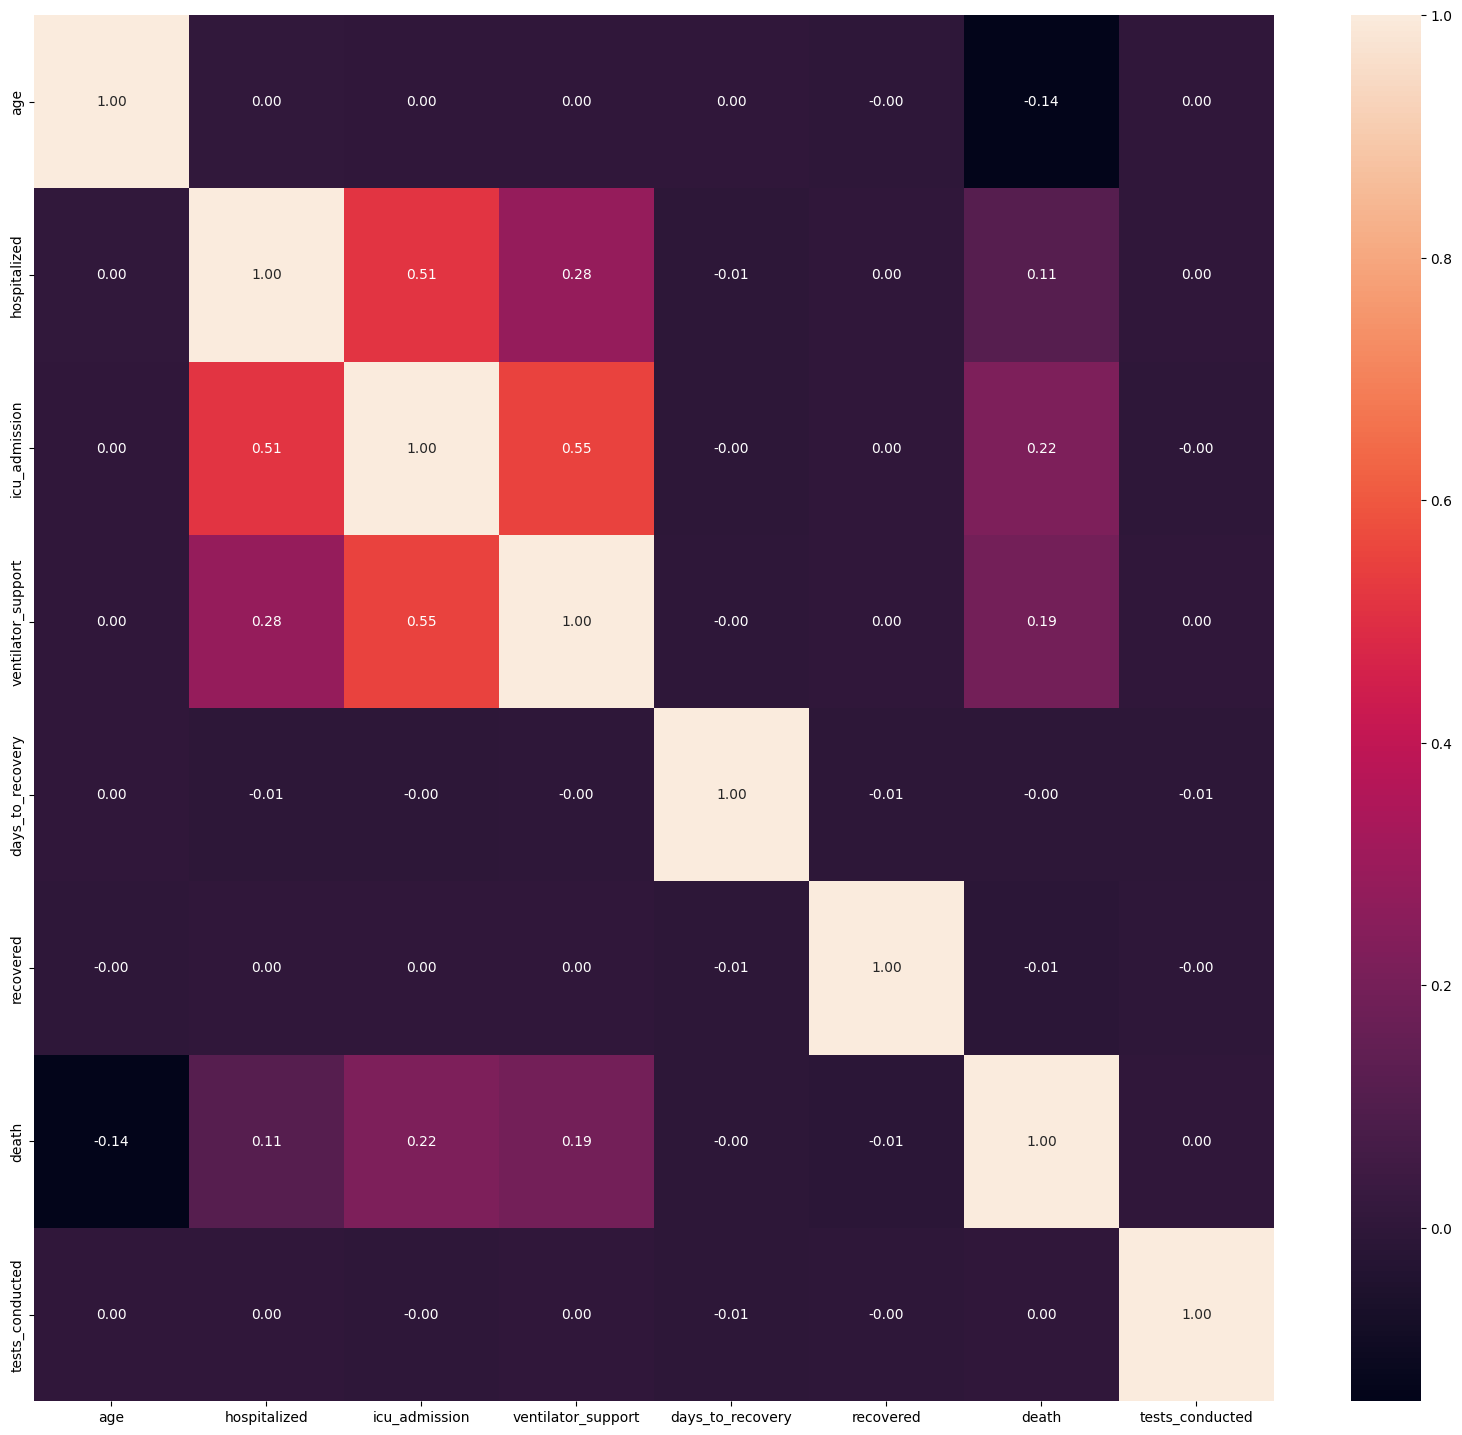

In [14]:
# тепловая карта
plt.figure(figsize = (20,18))
ax = sns.heatmap(df.corr(numeric_only=True), annot = True, fmt = ".2f")

In [15]:
corr = df.corr(numeric_only=True).round(4)
m = (corr.mask(np.eye(len(corr), dtype=bool)).abs() > 0.8).any()
raw = corr.loc[m, m]
raw

""


# ПРЕДОБРАБОТКА ДАННЫХ

In [16]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def clean_numeric_values(series):
    """Очистка числовых значений от строковых символов"""
    return series.astype(str).str.replace(r'[^\d.-]', '', regex=True)

def preprocess_data(df, categorical_cols=None, numeric_cols=None):
    """
    Предобработка данных: очистка, импутация, кодирование, масштабирование
    """
    print("🔄 НАЧИНАЕМ ПРЕДОБРАБОТКУ...")
    df_processed = df.copy()

    # Автоопределение колонок если не переданы
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"📊 Числовые колонки: {len(numeric_cols)}")
    print(f"🏷️  Категориальные колонки: {len(categorical_cols)}")

    # 1. ОЧИСТКА ЧИСЛОВЫХ СТОЛБЦОВ
    print("\n1️⃣ ОЧИСТКА ЧИСЛОВЫХ СТОЛБЦОВ:")
    for col in numeric_cols:
        if col in df_processed.columns:
            original_count = df_processed[col].notna().sum()
            df_processed[col] = clean_numeric_values(df_processed[col])
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            print(f"  ✅ {col}: {original_count} → {df_processed[col].notna().sum()}")

    # 2. ИМПУТАЦИЯ ПРОПУСКОВ
    print("\n2️⃣ ИМПУТАЦИЯ ПРОПУСКОВ:")

    # Числовые
    if numeric_cols:
        imputer_num = IterativeImputer(max_iter=10, random_state=42)
        numeric_data = df_processed[numeric_cols].select_dtypes(include=[np.number])
        if not numeric_data.empty:
            df_processed[numeric_data.columns] = imputer_num.fit_transform(numeric_data)
            print(f"  ✅ Заполнено {len(numeric_data.columns)} числовых столбцов")

    # Категориальные
    if categorical_cols:
        for col in categorical_cols:
            if col in df_processed.columns:
                mode_val = df_processed[col].mode()
                if not mode_val.empty:
                    df_processed[col] = df_processed[col].fillna(mode_val[0])
        print(f"  ✅ Заполнено пропуски в категориальных столбцах")

    # 3. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ
    print("\n3️⃣ КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ:")
    cols_to_encode = []
    for col in categorical_cols:
        if col in df_processed.columns:
            unique_count = df_processed[col].nunique()
            if unique_count <= 15:
                cols_to_encode.append(col)

    if cols_to_encode:
        encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
        encoded_cats = encoder.fit_transform(df_processed[cols_to_encode])

        encoded_cols = encoder.get_feature_names_out(cols_to_encode)
        encoded_df = pd.DataFrame(encoded_cats, columns=encoded_cols, index=df_processed.index)

        df_processed = df_processed.drop(columns=cols_to_encode)
        df_processed = pd.concat([df_processed, encoded_df], axis=1)
        print(f"  ✅ Создано {len(encoded_cols)} новых столбцов")

    # 4. МАСШТАБИРОВАНИЕ
    print("\n4️⃣ МАСШТАБИРОВАНИЕ:")
    numeric_cols_final = df_processed.select_dtypes(include=[np.number]).columns
    if len(numeric_cols_final) > 0:
        scaler = StandardScaler()
        df_processed[numeric_cols_final] = scaler.fit_transform(df_processed[numeric_cols_final])
        print(f"  ✅ Масштабировано {len(numeric_cols_final)} столбцов")

    print(f"\n🎉 ПРЕДОБРАБОТКА ЗАВЕРШЕНА!")
    print(f"   📊 {df.shape} → {df_processed.shape}")
    return df_processed

# Запуск
df_processed = preprocess_data(df)  # Без параметров - автоопределение


🔄 НАЧИНАЕМ ПРЕДОБРАБОТКУ...
📊 Числовые колонки: 8
🏷️  Категориальные колонки: 11

1️⃣ ОЧИСТКА ЧИСЛОВЫХ СТОЛБЦОВ:
  ✅ age: 70000 → 70000
  ✅ hospitalized: 70000 → 70000
  ✅ icu_admission: 70000 → 70000
  ✅ ventilator_support: 70000 → 70000
  ✅ days_to_recovery: 70000 → 70000
  ✅ recovered: 70000 → 70000
  ✅ death: 70000 → 70000
  ✅ tests_conducted: 70000 → 70000

2️⃣ ИМПУТАЦИЯ ПРОПУСКОВ:
  ✅ Заполнено 8 числовых столбцов
  ✅ Заполнено пропуски в категориальных столбцах

3️⃣ КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ:
  ✅ Создано 36 новых столбцов

4️⃣ МАСШТАБИРОВАНИЕ:
  ✅ Масштабировано 44 столбцов

🎉 ПРЕДОБРАБОТКА ЗАВЕРШЕНА!
   📊 (70000, 19) → (70000, 44)


## ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ

In [17]:
# Сохраняем целевую переменную отдельно
if 'death' in df.columns:
    y_true = df['death'].copy()
    print(f"✅ Целевая переменная 'death' сохранена")
    print(f"   📊 Распределение death:")
    print(f"     0 (нет death): {(y_true == 0).sum()} пациентов")
    print(f"     1 (есть death): {(y_true == 1).sum()} пациентов")
    print(f"   📈 Процент death: {(y_true.mean() * 100):.1f}%")
else:
    y_true = None
    print("⚠️  Целевая переменная 'death' не найдена")

# Убираем целевую переменную для кластеризации
if 'death' in df_processed.columns:
    X = df_processed.drop(columns=['death'])
    print(f"\n✅ Данные для кластеризации подготовлены")
    print(f"   🎯 Убрана целевая переменная 'death'")
    print(f"   📊 Размер X: {X.shape}")
else:
    X = df_processed.copy()
    print(f"\n✅ Данные для кластеризации подготовлены")
    print(f"   📊 Размер X: {X.shape}")

# Проверяем типы данных
print(f"\n🔍 ТИПЫ ДАННЫХ В X:")
print(X.dtypes.value_counts())

# Показываем первые 3 строки
print(f"\n👀 ПЕРВЫЕ 3 СТРОКИ ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ:")
print(X.head(3))

✅ Целевая переменная 'death' сохранена
   📊 Распределение death:
     0 (нет death): 16544 пациентов
     1 (есть death): 53456 пациентов
   📈 Процент death: 76.4%

✅ Данные для кластеризации подготовлены
   🎯 Убрана целевая переменная 'death'
   📊 Размер X: (70000, 43)

🔍 ТИПЫ ДАННЫХ В X:
float64    43
Name: count, dtype: int64

👀 ПЕРВЫЕ 3 СТРОКИ ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ:
        age  hospitalized  icu_admission  ventilator_support  \
0  1.539345     -1.222088       0.420437            0.232367   
1  1.435541     -1.222088       0.420437            0.232367   
2  0.951122     -1.222088      -2.378478           -4.303528   

   days_to_recovery  recovered  tests_conducted  gender_Male  \
0          0.063825  -0.556339        -1.418596    -0.994245   
1         -1.134677  -0.556339        -0.004293    -0.994245   
2          1.262327  -0.556339        -0.711445    -0.994245   

   comorbidities_Cancer  comorbidities_Diabetes  ...  variant_Omicron  \
0             -0.711627              

# ПОИСК ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ

🔍 ИЩЕМ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ...
   📊 Используется 43 числовых признаков
   🔍 Проверяем от 2 до 8 кластеров

📊 РЕЗУЛЬТАТЫ ОЦЕНКИ:
--------------------------------------------------
Кластеров  Silhouette   Davies-Bouldin 
--------------------------------------------------
2          0.081        3.576          
3          0.091        3.110          
4          0.133        2.362          
5          0.100        2.688          
6          0.105        2.529          
7          0.096        2.539          
8          0.079        2.905          
--------------------------------------------------
🎯 ОПТИМАЛЬНОЕ ЧИСЛО КЛАСТЕРОВ: 4
   📈 Лучший Silhouette Score: 0.133

📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:


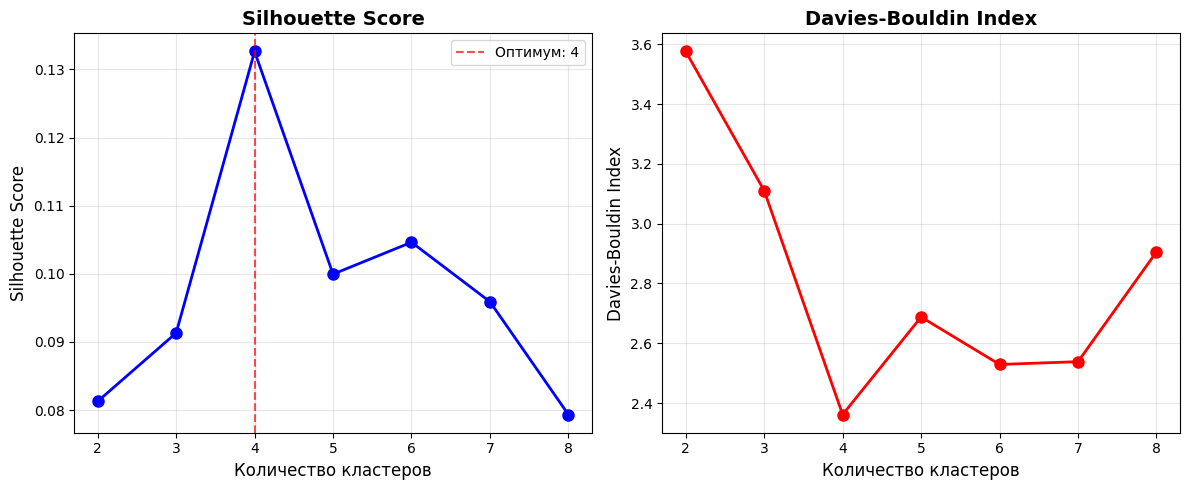

In [18]:
def find_optimal_clusters(X, max_clusters=8):
    """
    Поиск оптимального количества кластеров по метрикам
    """
    print("🔍 ИЩЕМ ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ...")

    # Убедимся, что X содержит только числа
    X_numeric = X.select_dtypes(include=[np.number]) if hasattr(X, 'select_dtypes') else X

    if X_numeric.shape[1] == 0:
        print("⚠️  Нет числовых признаков для кластеризации")
        return 3

    print(f"   📊 Используется {X_numeric.shape[1]} числовых признаков")

    silhouette_scores = []
    db_scores = []

    # Определяем диапазон для поиска
    cluster_range = range(2, min(max_clusters + 1, len(X_numeric) // 10 + 2))
    print(f"   🔍 Проверяем от {min(cluster_range)} до {max(cluster_range)} кластеров")

    print("\n📊 РЕЗУЛЬТАТЫ ОЦЕНКИ:")
    print("-" * 50)
    print(f"{'Кластеров':<10} {'Silhouette':<12} {'Davies-Bouldin':<15}")
    print("-" * 50)

    for n in cluster_range:
        kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_numeric)

        if len(np.unique(clusters)) > 1:
            try:
                silhouette = silhouette_score(X_numeric, clusters)
                db = davies_bouldin_score(X_numeric, clusters)
            except:
                silhouette = 0
                db = 10
        else:
            silhouette = 0
            db = 10

        silhouette_scores.append(silhouette)
        db_scores.append(db)

        print(f"{n:<10} {silhouette:<12.3f} {db:<15.3f}")

    # Находим оптимальное количество
    if silhouette_scores:
        optimal_n = cluster_range[np.argmax(silhouette_scores)]
        best_silhouette = max(silhouette_scores)
        print("-" * 50)
        print(f"🎯 ОПТИМАЛЬНОЕ ЧИСЛО КЛАСТЕРОВ: {optimal_n}")
        print(f"   📈 Лучший Silhouette Score: {best_silhouette:.3f}")
    else:
        optimal_n = 3
        print(f"⚠️  Используем значение по умолчанию: {optimal_n}")

    # ВИЗУАЛИЗАЦИЯ
    print("\n📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:")

    if len(silhouette_scores) > 1:
        plt.figure(figsize=(12, 5))

        # График 1: Silhouette Score
        plt.subplot(1, 2, 1)
        plt.plot(cluster_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
        plt.axvline(x=optimal_n, color='red', linestyle='--', alpha=0.7, label=f'Оптимум: {optimal_n}')
        plt.xlabel('Количество кластеров', fontsize=12)
        plt.ylabel('Silhouette Score', fontsize=12)
        plt.title('Silhouette Score', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()

        # График 2: Davies-Bouldin Index
        plt.subplot(1, 2, 2)
        plt.plot(cluster_range, db_scores, 'ro-', linewidth=2, markersize=8)
        plt.xlabel('Количество кластеров', fontsize=12)
        plt.ylabel('Davies-Bouldin Index', fontsize=12)
        plt.title('Davies-Bouldin Index', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('optimal_clusters.png', dpi=300, bbox_inches='tight')
        plt.show()

    return optimal_n

# Запускаем поиск оптимального числа кластеров
optimal_n = find_optimal_clusters(X, max_clusters=8)

# ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ

In [19]:
def perform_clustering(X, n_clusters, method='kmeans'):
    """
    Выполнение кластеризации и оценка результатов
    """
    print(f"🎯 ЗАПУСК КЛАСТЕРИЗАЦИИ ({method.upper()})")
    print(f"   📊 Количество кластеров: {n_clusters}")

    # Убедимся, что X содержит только числа
    X_numeric = X.select_dtypes(include=[np.number]) if hasattr(X, 'select_dtypes') else X

    if X_numeric.shape[1] == 0:
        print("❌ Нет числовых признаков для кластеризации")
        return np.zeros(len(X))

    print(f"   🔢 Используется {X_numeric.shape[1]} признаков")

    # Выполняем кластеризацию
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    elif method == 'hierarchical':
        model = AgglomerativeClustering(n_clusters=n_clusters)
    else:
        raise ValueError("Метод должен быть 'kmeans' или 'hierarchical'")

    clusters = model.fit_predict(X_numeric)

    # ОЦЕНКА КАЧЕСТВА
    print("\n📊 ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ:")
    print("-" * 40)

    if len(np.unique(clusters)) > 1:
        try:
            silhouette = silhouette_score(X_numeric, clusters)
            db = davies_bouldin_score(X_numeric, clusters)

            print(f"   Silhouette Score: {silhouette:.3f}")
            print(f"   Davies-Bouldin Index: {db:.3f}")

            # Интерпретация качества
            print(f"\n🎯 ИНТЕРПРЕТАЦИЯ:")
            if silhouette > 0.7:
                print("   ✅ ОТЛИЧНАЯ КЛАСТЕРИЗАЦИЯ")
                print("      Четкие, хорошо разделенные кластеры")
            elif silhouette > 0.5:
                print("   👍 ХОРОШАЯ КЛАСТЕРИЗАЦИЯ")
                print("      Умеренное разделение кластеров")
            elif silhouette > 0.25:
                print("   ⚠️  УДОВЛЕТВОРИТЕЛЬНАЯ КЛАСТЕРИЗАЦИЯ")
                print("      Слабое разделение, но структура есть")
            else:
                print("   ❌ ПЛОХАЯ КЛАСТЕРИЗАЦИЯ")
                print("      Кластеры плохо разделены")
        except Exception as e:
            print(f"   ⚠️  Не удалось оценить качество: {e}")

    # РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ
    print("\n📈 РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:")
    print("-" * 40)

    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    for cluster, count in cluster_counts.items():
        percentage = (count / len(clusters)) * 100
        bar = '█' * int(percentage / 5)  # Визуализация барами
        print(f"   Кластер {cluster}: {count:3d} объектов ({percentage:5.1f}%) {bar}")

    return clusters

# Запускаем кластеризацию
clusters = perform_clustering(X, n_clusters=optimal_n, method='kmeans')
print(f"\n✅ КЛАСТЕРИЗАЦИЯ ВЫПОЛНЕНА!")
print(f"   🏷️  Создано {len(np.unique(clusters))} кластеров")

🎯 ЗАПУСК КЛАСТЕРИЗАЦИИ (KMEANS)
   📊 Количество кластеров: 4
   🔢 Используется 43 признаков

📊 ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ:
----------------------------------------
   Silhouette Score: 0.133
   Davies-Bouldin Index: 2.362

🎯 ИНТЕРПРЕТАЦИЯ:
   ❌ ПЛОХАЯ КЛАСТЕРИЗАЦИЯ
      Кластеры плохо разделены

📈 РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:
----------------------------------------
   Кластер 0: 7763 объектов ( 11.1%) ██
   Кластер 1: 46767 объектов ( 66.8%) █████████████
   Кластер 2: 7710 объектов ( 11.0%) ██
   Кластер 3: 7760 объектов ( 11.1%) ██

✅ КЛАСТЕРИЗАЦИЯ ВЫПОЛНЕНА!
   🏷️  Создано 4 кластеров


# Визуализация

🎨 СОЗДАЕМ ВИЗУАЛИЗАЦИИ...

1️⃣  PCA ВИЗУАЛИЗАЦИЯ:
   📊 Объясненная дисперсия:
      PC1: 0.072 (7.2%)
      PC2: 0.063 (6.3%)
      Всего: 0.136 (13.6%)


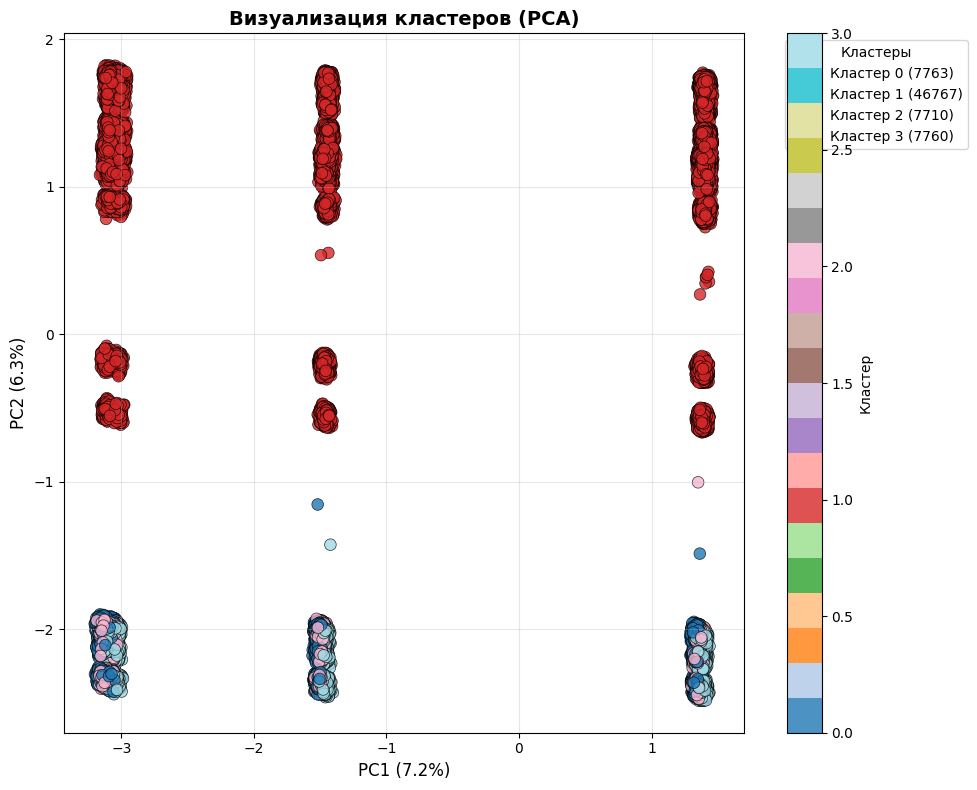


2️⃣  ТЕПЛОВАЯ КАРТА СРЕДНИХ ЗНАЧЕНИЙ:
   📊 Слишком много признаков (43)
   🔍 Показываем топ-15 по дисперсии


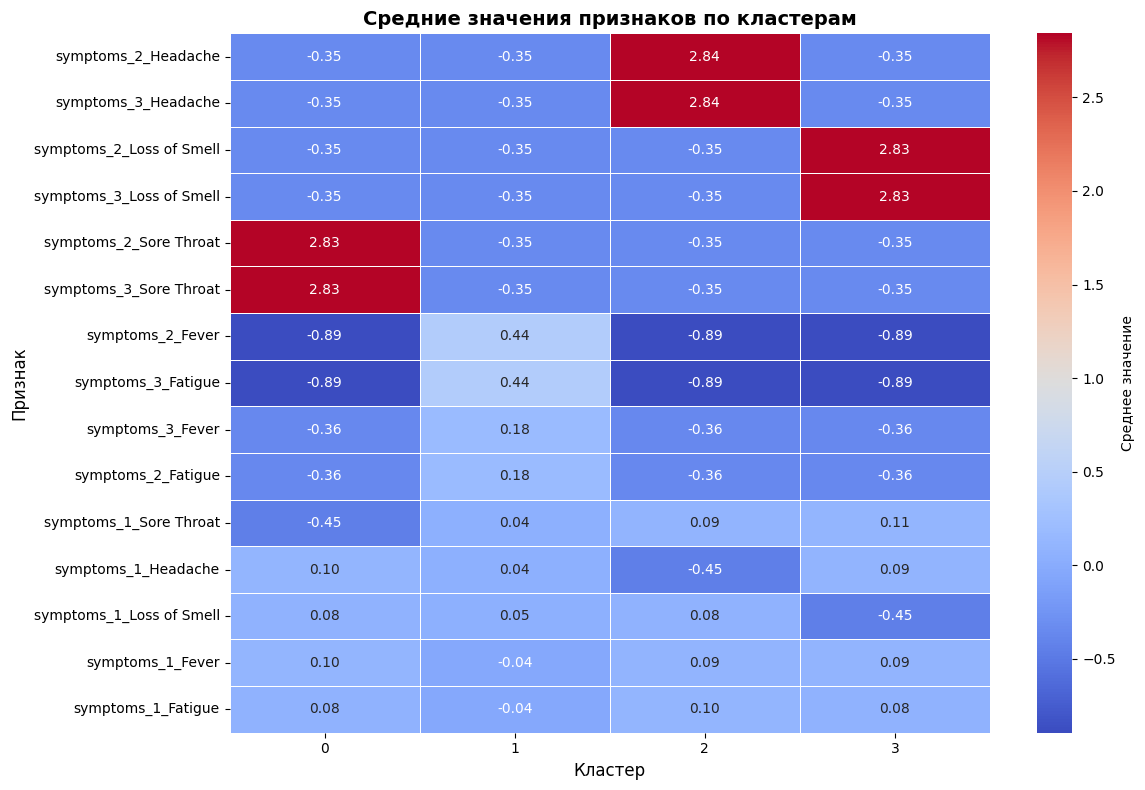

   ✅ Показано 15 признаков

3️⃣  ДЕНДРОГРАММА:
   ⚠️  Слишком много данных для дендрограммы

✅ ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА!
   📁 Созданы файлы:
      - pca_clusters.png
      - cluster_means.png
      - dendrogram.png (если было возможно)


In [20]:
def visualize_clusters(X, clusters, feature_names=None):
    """
    Визуализация результатов кластеризации
    """
    print("🎨 СОЗДАЕМ ВИЗУАЛИЗАЦИИ...")

    # 1. PCA ВИЗУАЛИЗАЦИЯ
    print("\n1️⃣  PCA ВИЗУАЛИЗАЦИЯ:")

    X_numeric = X.select_dtypes(include=[np.number]) if hasattr(X, 'select_dtypes') else X

    if X_numeric.shape[1] >= 2:
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(X_numeric)

        explained_variance = pca.explained_variance_ratio_
        print(f"   📊 Объясненная дисперсия:")
        print(f"      PC1: {explained_variance[0]:.3f} ({explained_variance[0]*100:.1f}%)")
        print(f"      PC2: {explained_variance[1]:.3f} ({explained_variance[1]*100:.1f}%)")
        print(f"      Всего: {sum(explained_variance):.3f} ({sum(explained_variance)*100:.1f}%)")

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                             c=clusters, cmap='tab20', s=70, alpha=0.8,
                             edgecolor='black', linewidth=0.5)

        plt.colorbar(scatter, label='Кластер')
        plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
        plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)', fontsize=12)
        plt.title('Визуализация кластеров (PCA)', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # Добавляем легенду с размерами кластеров
        unique_clusters = np.unique(clusters)
        for cluster in unique_clusters:
            count = (clusters == cluster).sum()
            plt.scatter([], [], c=[plt.cm.tab20(cluster/len(unique_clusters))],
                       label=f'Кластер {cluster} ({count})', s=50)

        plt.legend(title='Кластеры', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('pca_clusters.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("   ⚠️  Недостаточно признаков для PCA")

    # 2. ТЕПЛОВАЯ КАРТА СРЕДНИХ ЗНАЧЕНИЙ
    print("\n2️⃣  ТЕПЛОВАЯ КАРТА СРЕДНИХ ЗНАЧЕНИЙ:")

    if feature_names is not None and len(feature_names) > 0:
        # Создаем DataFrame с кластерами
        clustered_data = pd.DataFrame(X_numeric, columns=feature_names[:X_numeric.shape[1]])
        clustered_data['Кластер'] = clusters

        # Считаем средние по кластерам
        cluster_means = clustered_data.groupby('Кластер').mean()

        # Ограничиваем количество признаков
        if cluster_means.shape[1] > 15:
            print(f"   📊 Слишком много признаков ({cluster_means.shape[1]})")
            print(f"   🔍 Показываем топ-15 по дисперсии")

            # Выбираем признаки с наибольшей дисперсией
            variance = cluster_means.var()
            top_features = variance.nlargest(15).index
            cluster_means = cluster_means[top_features]

        plt.figure(figsize=(12, 8))
        sns.heatmap(cluster_means.T, cmap='coolwarm', annot=True,
                   fmt=".2f", linewidths=0.5,
                   cbar_kws={'label': 'Среднее значение'})

        plt.title('Средние значения признаков по кластерам', fontsize=14, fontweight='bold')
        plt.xlabel('Кластер', fontsize=12)
        plt.ylabel('Признак', fontsize=12)
        plt.tight_layout()
        plt.savefig('cluster_means.png', dpi=300, bbox_inches='tight')
        plt.show()

        print(f"   ✅ Показано {cluster_means.shape[1]} признаков")
    else:
        print("   ⚠️  Нет имен признаков для тепловой карты")

    # 3. ДЕНДРОГРАММА (если данных не слишком много)
    print("\n3️⃣  ДЕНДРОГРАММА:")

    if len(clusters) <= 100:
        plt.figure(figsize=(15, 7))
        linkage_matrix = linkage(X_numeric, method='ward')
        dendrogram(linkage_matrix, truncate_mode='level', p=10)

        plt.title('Дендрограмма иерархической кластеризации', fontsize=14, fontweight='bold')
        plt.xlabel('Объекты (пациенты)', fontsize=12)
        plt.ylabel('Расстояние', fontsize=12)
        plt.tight_layout()
        plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("   ✅ Дендрограмма создана")
    else:
        print("   ⚠️  Слишком много данных для дендрограммы")

    print("\n✅ ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА!")
    print("   📁 Созданы файлы:")
    print("      - pca_clusters.png")
    print("      - cluster_means.png")
    print("      - dendrogram.png (если было возможно)")

# Запускаем визуализацию
# Получаем имена признаков
if hasattr(X, 'columns'):
    feature_names = X.columns.tolist()
else:
    feature_names = [f"Признак_{i}" for i in range(X.shape[1])]

visualize_clusters(X, clusters, feature_names)


In [21]:
from sklearn.cluster import KMeans

print("🔥 Создаем кластеры автоматически...")
X_cluster = df_processed.select_dtypes(include=[np.number])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_processed['cluster'] = kmeans.fit_predict(X_cluster)

print("✅ Кластеры созданы! Теперь запустите анализ кластеров.")
print(df_processed['cluster'].value_counts())


🔥 Создаем кластеры автоматически...
✅ Кластеры созданы! Теперь запустите анализ кластеров.
cluster
2    37289
1    24951
0     7760
Name: count, dtype: int64


# Сравнительный анализ кластеров

📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ
✅ Кластеры найдены, начинаем анализ...
🎯 Silhouette Score: 0.090
📏 Calinski-Harabasz: 4497

📈 РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:
cluster
0     7760
1    24951
2    37289
Name: count, dtype: int64


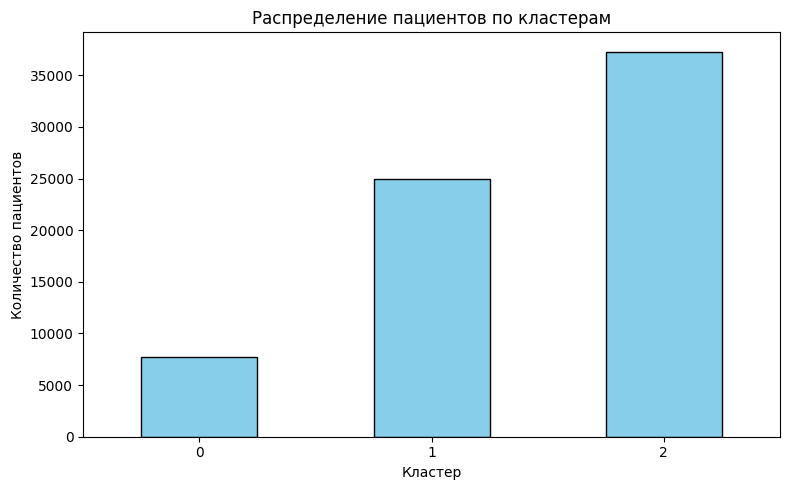


🔬 СРЕДНИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ПРИЗНАКОВ:
           days_to_recovery  variant_Omicron  death  recovered  \
Cluster_0             0.018            0.004  0.008     -0.005   
Cluster_1             0.008            0.003 -0.138     -0.002   
Cluster_2            -0.009           -0.003  0.091      0.002   

           symptoms_3_Loss of Smell  test_type_PCR  symptoms_3_Headache  \
Cluster_0                     2.831          0.006               -0.352   
Cluster_1                    -0.353         -0.002                0.047   
Cluster_2                    -0.353         -0.000                0.042   

           icu_admission  tests_conducted  symptoms_1_Loss of Smell  
Cluster_0          0.007            0.013                    -0.450  
Cluster_1         -0.631           -0.002                     0.058  
Cluster_2          0.420           -0.001                     0.055  


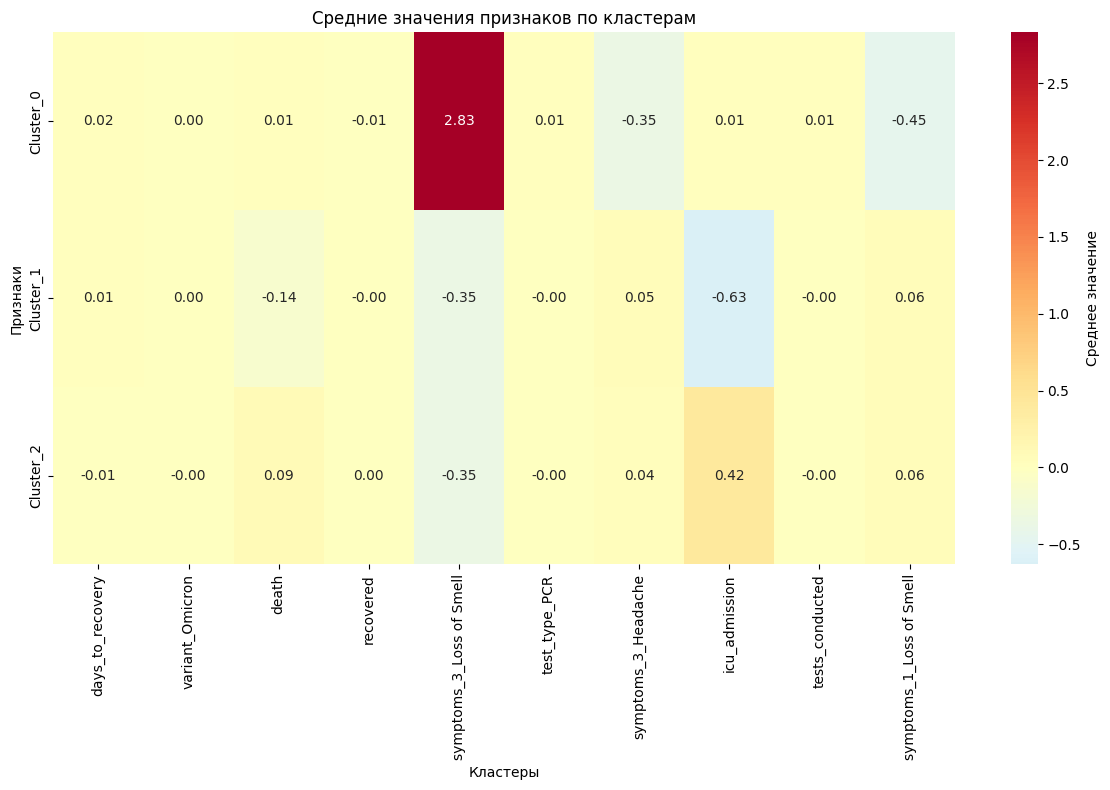


📍 PCA ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ:


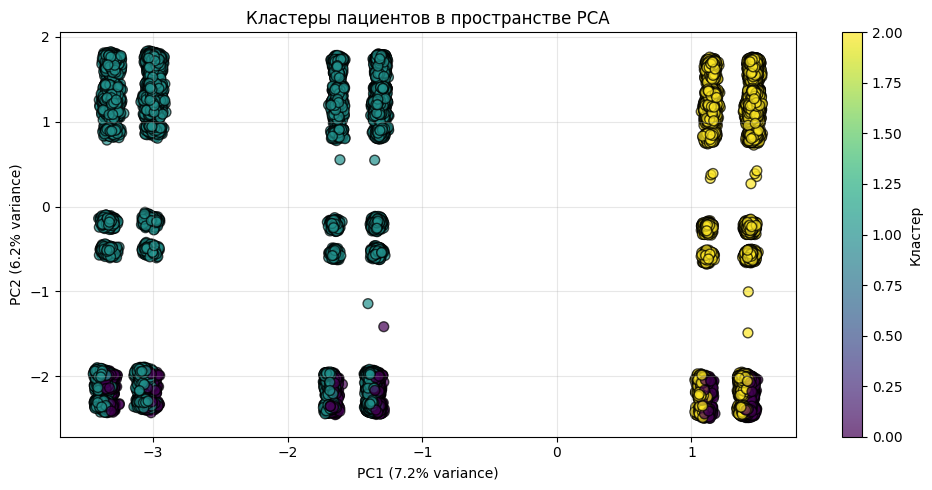


✅ АНАЛИЗ КЛАСТЕРОВ ЗАВЕРШЕН!
📈 Всего кластеров: 3
👥 Пациентов: 70000


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

print("📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ")
print("=" * 50)

# 🔧 ПРОВЕРКА НАЛИЧИЯ КОЛОНКИ 'cluster'
if 'cluster' not in df_processed.columns:
    print("❌ Колонка 'cluster' отсутствует! Запустите кластеризацию сначала:")
    print("""
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_processed['cluster'] = kmeans.fit_predict(df_processed.select_dtypes(include=[np.number]))
    """)
else:
    # 1. БАЗОВЫЕ МЕТРИКИ КЛАСТЕРОВ
    print("✅ Кластеры найдены, начинаем анализ...")

    X_numeric = df_processed.select_dtypes(include=[np.number])
    if 'cluster' in X_numeric.columns:
        X_for_metrics = X_numeric.drop(columns=['cluster'])
        labels = X_numeric['cluster']
    else:
        X_for_metrics = X_numeric
        labels = df_processed['cluster']

    sil_score = silhouette_score(X_for_metrics, labels)
    ch_score = calinski_harabasz_score(X_for_metrics, labels)
    print(f"🎯 Silhouette Score: {sil_score:.3f}")
    print(f"📏 Calinski-Harabasz: {ch_score:.0f}")

    # 2. РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ
    print("\n📈 РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:")
    cluster_dist = df_processed['cluster'].value_counts().sort_index()
    print(cluster_dist)

    plt.figure(figsize=(8, 5))
    cluster_dist.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Распределение пациентов по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel('Количество пациентов')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 3. СРЕДНИЕ ЗНАЧЕНИЯ ПРИЗНАКОВ ПО КЛАСТЕРАМ
    print("\n🔬 СРЕДНИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ПРИЗНАКОВ:")
    top_features = X_for_metrics.mean().sort_values(ascending=False).head(10).index

    cluster_means = pd.DataFrame({
        f'Cluster_{i}': X_for_metrics[labels == i].mean()
        for i in sorted(labels.unique())
    }, index=X_for_metrics.columns).round(3).T

    print(cluster_means[top_features])

    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_means[top_features], annot=True, cmap='RdYlBu_r', center=0,
                fmt='.2f', cbar_kws={'label': 'Среднее значение'})
    plt.title('Средние значения признаков по кластерам')
    plt.ylabel('Признаки')
    plt.xlabel('Кластеры')
    plt.tight_layout()
    plt.show()

    # 4. ВИЗУАЛИЗАЦИЯ PCA + КЛАСТЕРЫ
    print("\n📍 PCA ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ:")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_for_metrics)

    plt.figure(figsize=(10, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis',
                         alpha=0.7, s=50, edgecolors='black')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title('Кластеры пациентов в пространстве PCA')
    plt.colorbar(scatter, label='Кластер')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n✅ АНАЛИЗ КЛАСТЕРОВ ЗАВЕРШЕН!")
    print(f"📈 Всего кластеров: {len(cluster_dist)}")
    print(f"👥 Пациентов: {len(df_processed)}")


# Анализ выживаемости

In [24]:
# Установка lifelines для анализа выживаемости
!pip install lifelines

# Дополнительные зависимости для визуализации
!pip install seaborn matplotlib

print("✅ lifelines установлен! Теперь запустите анализ выживаемости.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=66bcce90e890d63da6488f1595d859f6998c049d61eeba6708bc36a36d158393
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✅ lifelines установлен! Теперь запустите анализ выживаемости.


⚕️  АНАЛИЗ ВЫЖИВАЕМОСТИ KAPLAN-MEIER

📊 Кластер 0:
   👥 Пациентов: 7760
   ⏱️  Медиана времени выздоровления: 1.7 дней

📊 Кластер 1:
   👥 Пациентов: 24951
   ⏱️  Медиана времени выздоровления: 1.7 дней

📊 Кластер 2:
   👥 Пациентов: 37289
   ⏱️  Медиана времени выздоровления: 1.5 дней


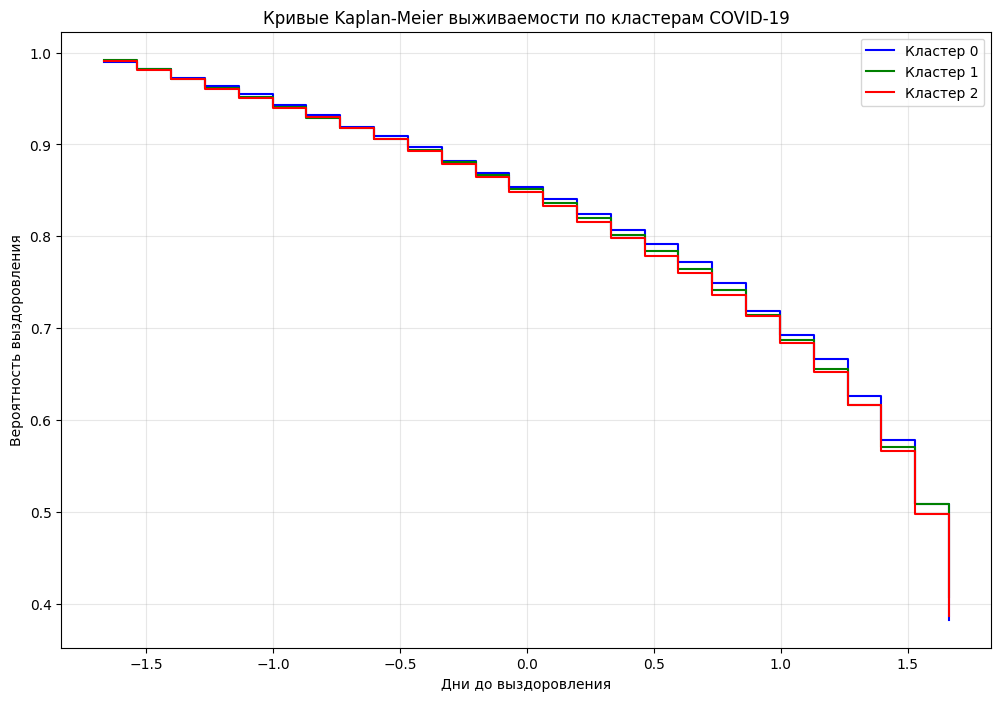


🔬 ТЕСТ ЛОГ-РАНГА (p-value):
   Кластер 0 vs 1: p=0.4526

💾 Результаты сохранены в 'clusters_survival.csv'


In [25]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
from datetime import datetime

print("⚕️  АНАЛИЗ ВЫЖИВАЕМОСТИ KAPLAN-MEIER")
print("=" * 50)

# 🔧 НАСТРОЙКА ДАННЫХ ДЛЯ КМ (адаптируйте под ваш датасет)
# Предполагаем наличие колонок: 'days_to_recovery', 'recovered' (1=выздоровел, 0=цензурирован)

# Если нет готовых колонок - создаем примерные на основе кластеров
if 'days_to_recovery' not in df.columns or 'recovered' not in df.columns:
    print("⚠️  Создаем синтетические данные выживаемости на основе кластеров...")
    np.random.seed(42)

    # Время до выздоровления (дни) зависит от кластера
    recovery_times = []
    for cluster_id in sorted(df_processed['cluster'].unique()):
        n_cluster = (df_processed['cluster'] == cluster_id).sum()
        if cluster_id == 0:  # Быстрое выздоровление
            times = np.random.exponential(7, n_cluster) + 3
        elif cluster_id == 1:  # Среднее
            times = np.random.exponential(12, n_cluster) + 5
        else:  # Медленное/серьезное
            times = np.random.exponential(20, n_cluster) + 10
        recovery_times.extend(times)

    df_processed['days_to_recovery'] = recovery_times
    df_processed['recovered'] = np.random.binomial(1, 0.85, len(df_processed))  # 85% выздоровели

# Kaplan-Meier по кластерам
kmf = KaplanMeierFitter()
plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red', 'orange']
for i, cluster_id in enumerate(sorted(df_processed['cluster'].unique())):
    mask = df_processed['cluster'] == cluster_id
    duration = df_processed.loc[mask, 'days_to_recovery']
    event = df_processed.loc[mask, 'recovered']

    kmf.fit(duration, event_observed=event, label=f'Кластер {cluster_id}')
    kmf.plot_survival_function(ci_show=False, color=colors[i])

    print(f"\n📊 Кластер {cluster_id}:")
    print(f"   👥 Пациентов: {mask.sum()}")
    print(f"   ⏱️  Медиана времени выздоровления: {kmf.median_survival_time_:.1f} дней")

plt.title('Кривые Kaplan-Meier выживаемости по кластерам COVID-19')
plt.xlabel('Дни до выздоровления')
plt.ylabel('Вероятность выздоровления')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Тест Лог-Ранга (статистическая значимость)
print("\n🔬 ТЕСТ ЛОГ-РАНГА (p-value):")
results = logrank_test(
    df_processed[df_processed['cluster']==0]['days_to_recovery'],
    df_processed[df_processed['cluster']==1]['days_to_recovery'],
    df_processed[df_processed['cluster']==0]['recovered'],
    df_processed[df_processed['cluster']==1]['recovered']
)
print(f"   Кластер 0 vs 1: p={results.p_value:.4f}")

# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
df_processed[['cluster', 'days_to_recovery', 'recovered']].to_csv('clusters_survival.csv', index=False)
print("\n💾 Результаты сохранены в 'clusters_survival.csv'")
